# Big Data Analytics Project
### Group 55 – NOVA IMS
##### Spring Semester 2024/2025

## 📑 Table of Contents
- 1. Set Up
- 2. EDA + feature selection
- 3. Feature Engineering, Vectorization, Train-Val-Test Split
- 4. Linear Regression
- 5. Random Forest Regressor
- 6. GBT Regressor
- 7. Update Features
- 8. Results

## Set Up

In [0]:
# Install missing dependencies
%pip install mlflow
%pip install ucimlrepo

Python interpreter will be restarted.
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.1.1
    Not uninstalling typing-extensions at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-6bd2f186-853c-45a9-b8bf-aec2e90850e9
    Can't uninstall 'typing-extensions'. No files were found to uninstall.
  Attempting uninstall: requests
    Found existing installation: requests 2.27.1
    Not uninstalling requests at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-6bd2f186-853c-45a9-b8bf-aec2e90850e9
    Can't uninstall 'requests'. No files were found to uninstall.
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 2.0.1
    Not uninstalling markupsafe at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-6bd2f186-853c-45a9-b8bf-aec2e90850e

In [0]:
# import packages
import os
import pyspark
from pyspark.sql import SparkSession
from functools import reduce
from pyspark.sql import DataFrame
import pyspark.sql.functions as F
from pyspark.sql.functions import col, when, unix_timestamp, dayofweek, dayofmonth, udf, hour, minute, unix_timestamp, concat_ws
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pyspark.sql.types import IntegerType, NumericType, StringType, FloatType, DoubleType
import textwrap
from scipy.stats import ks_2samp
from sklearn.feature_selection import mutual_info_regression

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation

import mlflow
import mlflow.pyspark.ml

In [0]:
# Start Spark Session
spark = SparkSession.builder.appName("Predict price") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

In [0]:
# Load the dataset
data = spark.read.parquet('/dbfs/FileStore/clean/dataset_after_cleaning.parquet').limit(2000000)

In [0]:
# Check the data (number of rows, schema)
print(data.count())
data.printSchema()

2000000
root
 |-- VendorID: string (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: string (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: string (nullable = true)
 |-- DOLocationID: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- pickup

### Select columns that provide value and can be used for the analysis (are accessible at the time of analysis)
Exclude
- VendorID (indicates the TPEP provider that provided record) -> not relevant
- RatecodeID, payment_type, trip_duration_minutes, trip_speed_mph (at the end of the trip) -> not accessible
- fare_amount (at the end of the trip) -> not accessible
- tip_amount (substracted from the total amount since client can decide this. So we are predicting the price of the trip without tip.)

In [0]:
# drop above mentioned columns
data_filtered = data.drop("VendorID", "RatecodeID", "fare_amount", 'payment_type', 'trip_duration_minutes', 'trip_speed_mph')

In [0]:
# substract tip_amount
data_filtered = data_filtered.withColumn("total_amount", col("total_amount") - col("tip_amount")).drop("tip_amount")

In [0]:
# features with string datatypes can be turned to integers (except PU_DO_pair) 
[f[0] for f in data_filtered.dtypes if isinstance(data_filtered.schema[f[0]].dataType, (StringType))]

Out[7]: ['passenger_count', 'PULocationID', 'DOLocationID', 'PU_DO_pair']

In [0]:
# Extract day of week and hour features, change datatypes to integer values
df = data_filtered.withColumn("hour", hour("tpep_pickup_datetime")) \
    .withColumn("day_of_week", dayofweek("tpep_pickup_datetime")) 

# cast string columns to integer    
for string_col in ['passenger_count', 'PULocationID', 'DOLocationID']:
    df = df.withColumn(string_col, col(string_col).cast("int"))

# check that dtypes ok
[f[0] for f in df.dtypes if isinstance(df.schema[f[0]].dataType, (StringType))]

Out[6]: ['PU_DO_pair']

In [0]:
# we notice that improvement_surcharge, mta_tax, congestion_surcharge are categorical -> we use stringIndexer
print(df.groupBy("improvement_surcharge").count().show())
print(df.groupBy("mta_tax").count().show())
print(df.groupBy("congestion_surcharge").count().show())

+---------------------+-------+
|improvement_surcharge|  count|
+---------------------+-------+
|                  1.0|1365759|
|                  0.3| 634241|
+---------------------+-------+

None
+-------+-------+
|mta_tax|  count|
+-------+-------+
|    0.5|1986124|
|    0.0|  13872|
|   0.05|      3|
|    0.3|      1|
+-------+-------+

None
+--------------------+-------+
|congestion_surcharge|  count|
+--------------------+-------+
|                 2.5|1890507|
|                 0.0| 109491|
|                0.75|      2|
+--------------------+-------+

None


In [0]:
# cast improvement_surcharge, mta_tax, congestion_surcharge values to categorical using stringIndexer
for num_col in ['mta_tax', 'improvement_surcharge', 'congestion_surcharge']:
    df = df.withColumn(num_col, col(num_col).cast("string")) 
    stringIndexer = StringIndexer(inputCol=num_col, outputCol=f'{num_col}_indexed')
    df = stringIndexer.fit(df).transform(df)
    df = df.withColumn(f'{num_col}_indexed', col(f'{num_col}_indexed').cast("int")) 

In [0]:
# # of null values
number_of_nulls = df.filter(
    reduce(lambda x, y: x | y, [col(c).isNull() for c in df.columns])
).count()
print(number_of_nulls)

450


In [0]:
# remove all rows with any null values
df = df.dropna()

## EDA + feature selection

We split data to train, validation and test sets:
- Train set: Used to fit models.
- Validation set: Used to compare across model types (LR vsRF vs GBT) and feature sets.
- Test set: Used only once at the end to evaluate final chosen model — gives an unbiased estimate of generalization performance.
- In addition, CV on train set for RF and GBT: Used to tune hyperparameters (e.g. depth, max bins).

In [0]:
# Split data
train_data, val_data, test_data = df.randomSplit([0.6, 0.2, 0.2], seed=42)

### Categorical features

In [0]:
# select categorical features
categorical_features = [f[0] for f in df.dtypes if isinstance(train_data.schema[f[0]].dataType, (StringType, IntegerType))]
categorical_features

Out[36]: ['passenger_count',
 'PULocationID',
 'DOLocationID',
 'mta_tax',
 'improvement_surcharge',
 'congestion_surcharge',
 'airport_fee',
 'month',
 'year',
 'is_weekend',
 'is_holiday',
 'is_shared_ride',
 'has_toll',
 'PU_DO_pair',
 'has_congestion_fee',
 'hour',
 'day_of_week',
 'mta_tax_indexed',
 'improvement_surcharge_indexed',
 'congestion_surcharge_indexed']

In [0]:
# Remove 'mta_tax', 'improvement_surcharge', 'congestion_surcharge' and use indexed versions; remove PU_DO_pairs as well, since we have PU and DO locations separately
categorical_features = ['passenger_count',
 'PULocationID',
 'DOLocationID',
 'airport_fee',
 'is_weekend',
 'is_holiday',
 'is_shared_ride',
 'has_toll',
 'hour',
 'day_of_week',
 'mta_tax_indexed',
 'improvement_surcharge_indexed',
 'congestion_surcharge_indexed']

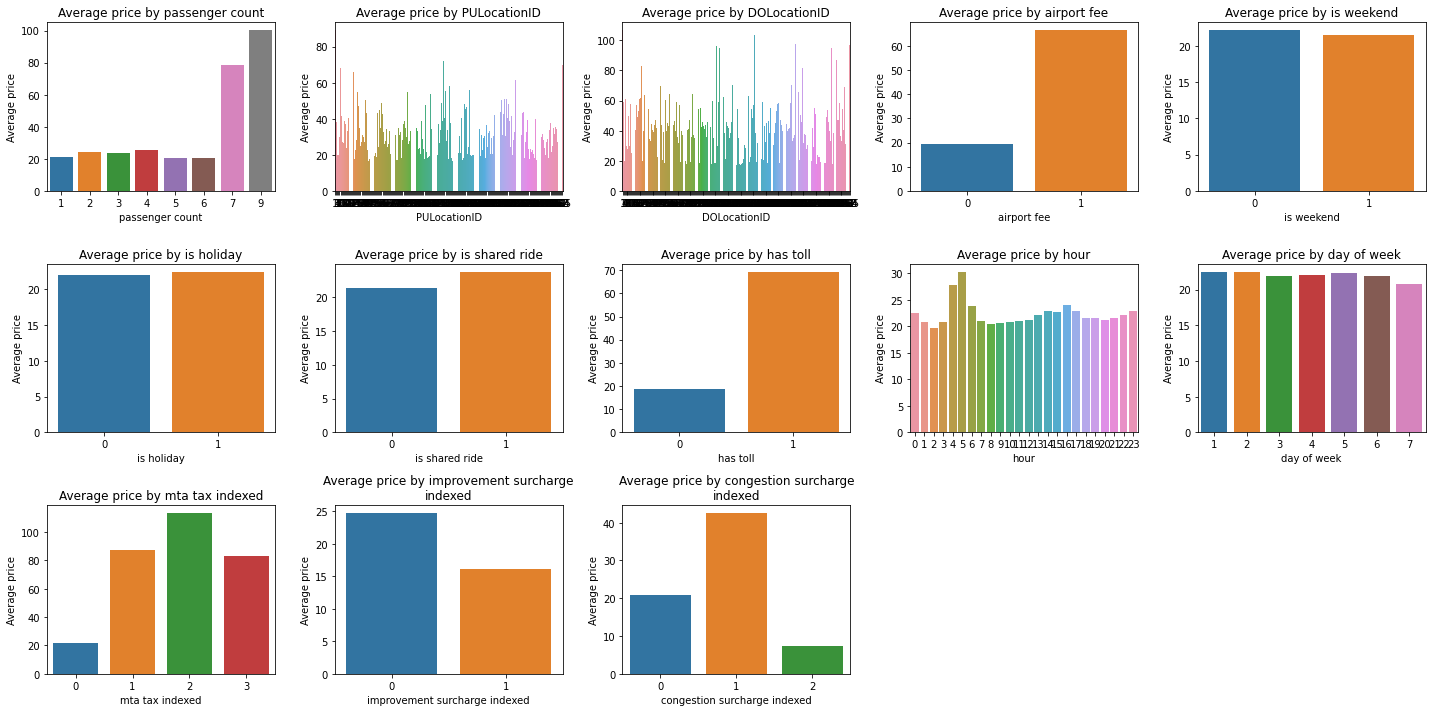

In [0]:
# EDA: categorical features
pd_df = train_data.toPandas()

# Set up the figure for multiple bar plots
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

# Plot each categorical feature against the mean count
for i, feature in enumerate(categorical_features):
    plot_df = pd_df.groupby(feature)[['total_amount']].mean().reset_index()
    sns.barplot(data=pd_df, x=feature, y="total_amount", ax=axes[i], estimator=np.mean, ci=None)
    axes[i].set_title("\n".join(textwrap.wrap(f'Average price by {feature.replace("_", " ")}', width=40)))
    axes[i].set_xlabel(feature.replace("_", " "))
    axes[i].set_ylabel("Average price")

fig.delaxes(axes[-1])
fig.delaxes(axes[-2])
plt.tight_layout()
plt.show()

The same values numerically:

In [0]:
# calculate average total_amounts for each group
for feature in categorical_features:
    train_data.groupBy(feature).avg("total_amount").orderBy("avg(total_amount)").show()

+---------------+------------------+
|passenger_count| avg(total_amount)|
+---------------+------------------+
|              6| 20.36710207852247|
|              5| 20.56744867131219|
|              1|21.397658211340012|
|              3| 23.58305322495779|
|              2|  24.0542746546159|
|              4|25.834722447984316|
|              7|           78.3825|
|              9|            100.05|
+---------------+------------------+

+------------+------------------+
|PULocationID| avg(total_amount)|
+------------+------------------+
|         237|  16.5292790453006|
|         141| 16.67501822241196|
|          41|16.835868347338828|
|         236| 16.95772163536241|
|         263| 17.00750223813842|
|         151| 17.03901894317074|
|          74|17.141008500772678|
|          75|17.171725479672684|
|         143|17.232188002926552|
|         238|17.267191372000738|
|         229|17.619452614379785|
|         239| 17.63381468249345|
|          24|17.806182318751812|
|         1

Observations: for features is_weekend, is_holiday, is_shared_ride, and day_of_week the average price do not differ significantly between groups

#### Mutual information
Calculate the mutual information scores

In [0]:
mi_features = ['passenger_count',
 #'PULocationID',
 #'DOLocationID',
 'airport_fee',
 'is_weekend',
 'is_holiday',
 'is_shared_ride',
 'has_toll',
 'hour',
 'day_of_week',
 'mta_tax_indexed',
 'improvement_surcharge_indexed',
 'congestion_surcharge_indexed']

mi_scores = mutual_info_regression(train_data.select(mi_features).toPandas(), train_data.select('total_amount').toPandas().squeeze())

mi_df = pd.DataFrame({
    'Feature': mi_features,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

mi_df

,Feature,MI Score
9,improvement_surcharge_indexed,0.455663
6,hour,0.271016
5,has_toll,0.207346
1,airport_fee,0.181585
10,congestion_surcharge_indexed,0.109734
2,is_weekend,0.037568
8,mta_tax_indexed,0.026799
7,day_of_week,0.025195
0,passenger_count,0.004899
4,is_shared_ride,0.004638


Exclude features: 
- 'day_of_week' (we keep 'is_weekend' that has higher MI-score)
- 'is_holiday' (no big differences on the average total_amount and low MI-score)
- 'has_toll' (we have numeric column 'tolls_amount')
- 'is_shared_ride' (we keep 'passenger_count' that has higher MI-score. The average total_amount did not differ significantly and the MI-score is low as well)
 

In [0]:
# final categorical features
categorical_features = ['passenger_count',
 'PULocationID',
 'DOLocationID',
 'airport_fee',
 'is_weekend',
 'hour',
 'mta_tax_indexed',
 'improvement_surcharge_indexed',
 'congestion_surcharge_indexed']

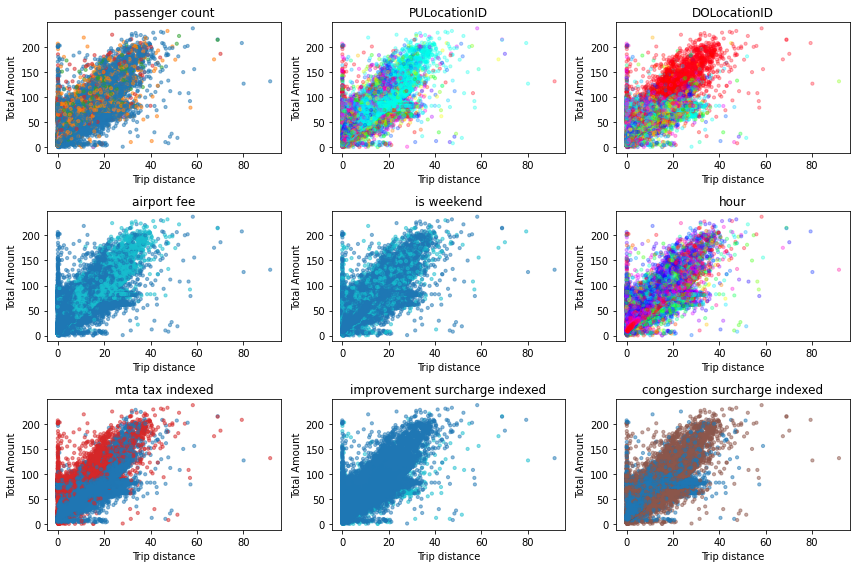

In [0]:
# Plot final features on trip_distance vs. total_amount scatter plot to see if we can visually detect some patterns
pandas_df = train_data.select(["trip_distance", "total_amount"] + categorical_features).toPandas()

# Set up the figure for multiple plots
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# Plot trip_distance vs. total_amount and color points according to the groups in each categorical feature
for i, feature in enumerate(categorical_features):
    if pandas_df[feature].nunique() <= 10:
        axes[i].scatter(
        pandas_df['trip_distance'],
        pandas_df['total_amount'],
        c=pandas_df[feature],
        cmap='tab10',
        alpha=0.5,
        s=10)
    else:
        axes[i].scatter(
            pandas_df['trip_distance'],
            pandas_df['total_amount'],
            c=pandas_df[feature],
            cmap=plt.cm.get_cmap('hsv', pandas_df[feature].nunique()), 
            alpha=0.3,
            s=10)
    axes[i].set_title(f'{feature.replace("_", " ")}')
    axes[i].set_xlabel('Trip distance')
    axes[i].set_ylabel("Total Amount")

plt.tight_layout()
plt.show()

### Numerical features

In [0]:
# select numerical features
numerical_features = [f[0] for f in df.dtypes if isinstance(train_data.schema[f[0]].dataType, DoubleType)]
numerical_features

Out[42]: ['trip_distance',
 'extra',
 'tolls_amount',
 'total_amount',
 'pickup_hour_decimal']

In [0]:
# remove 'total_amount' (target) and 'pickup_hour_decimal' (we have categorical variable hour)
numerical_features = ['trip_distance', 'extra', 'tolls_amount']

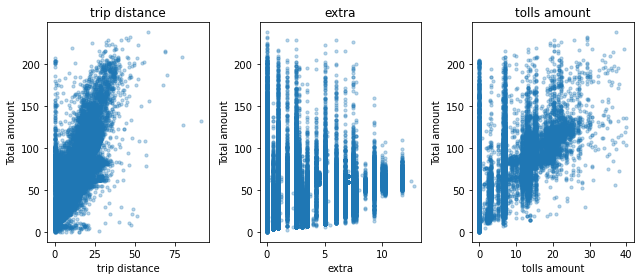

In [0]:
# Plot each numerical feature against total_amount
pandas_df = train_data.select(numerical_features + ['total_amount']).toPandas() 

# Set up the figure for multiple plots
fig, axes = plt.subplots(1, 3, figsize=(9,4))
axes = axes.flatten()

# Plot each feature against the total_amount
for i, feature in enumerate(numerical_features):
    axes[i].scatter(
            pandas_df[feature],
            pandas_df['total_amount'],
            alpha=0.3,
            s=10)
    axes[i].set_title(f'{feature.replace("_", " ")}')
    axes[i].set_ylabel('Total amount')
    axes[i].set_xlabel(f'{feature.replace("_", " ")}')

plt.tight_layout()
plt.show()

We observe that there are some relationships between the numerical features and the target variable. Let us next calculate correlation matrix.

In [0]:
# Create correlation matrix
assembler = VectorAssembler(inputCols=numerical_features + ['total_amount'],
outputCol='features')
df_corr_matrix = assembler.transform(train_data)
corr_matrix = Correlation.corr(df_corr_matrix, "features", "pearson").head()[0]

In [0]:
# Convert Spark DenseMatrix to NumPy array
corr_array = corr_matrix.toArray()

# Create DataFrame for seaborn
columns = numerical_features + ['total_amount']
corr_df = pd.DataFrame(corr_array, columns=columns, index=columns)

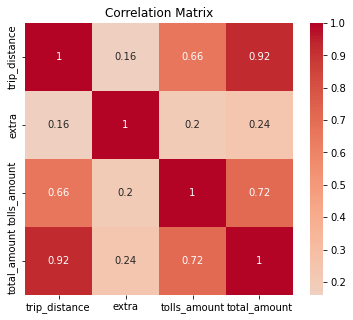

In [0]:
# plot correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

Since all numerical features show at least some correlation with the target variable, even if weak in the case of extra, we retain all of them at this stage. From the scatter plot, we observe that as the value of extra increases, the spread of total_amount decreases.

In [0]:
# final numerical features
numerical_features = ['trip_distance', 'extra', 'tolls_amount']

## Feature Engineering, Vectorization, Train-Test Split

In [0]:
# no need for indexer as all values doubles or integers
df.select(numerical_features+categorical_features).printSchema()

root
 |-- trip_distance: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- airport_fee: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- mta_tax_indexed: integer (nullable = true)
 |-- improvement_surcharge_indexed: integer (nullable = true)
 |-- congestion_surcharge_indexed: integer (nullable = true)



In [0]:
# features for baseline model
features = ['trip_distance'] 
# features for LR with all numerical features
features2 = numerical_features 
# all categorical and numerical features
features3 = categorical_features + numerical_features 

assembler = VectorAssembler(inputCols=features,
outputCol='features')

assembler2 = VectorAssembler(inputCols=features2, 
outputCol='features2')

assembler3 = VectorAssembler(inputCols=features3, 
outputCol='features3')

In [0]:
# Evaluators
evaluator_rmse = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="r2")

## Linear Regression

In [0]:
# Define Linear Regression model and scaler
mlflow.pyspark.ml.autolog(disable=True) 

lr = LinearRegression(featuresCol="features_scaled", labelCol="total_amount")
scaler = StandardScaler(inputCol='features', outputCol="features_scaled", withMean=True, withStd=True)

with mlflow.start_run(run_name="LR_Baseline_Model"):
    # Train the model
    pipeline = Pipeline(stages=[assembler, scaler, lr])
    lr_model = pipeline.fit(train_data)

    # Make predictions
    predictions = lr_model.transform(val_data)

    # Evaluate model
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")
    predictions.select("features", "total_amount", "prediction").show(10)

    # Model coefficients and intercept
    print(f"Coefficients: {lr_model.stages[-1].coefficients}")
    print(f"Intercept: {lr_model.stages[-1].intercept}")

Root Mean Squared Error (RMSE): 6.528093812117314
R^2: 0.8549461946142407
MAE: 3.855514578836618
+--------+------------+------------------+
|features|total_amount|        prediction|
+--------+------------+------------------+
|  [3.87]|        19.8|25.014672394680716|
| [17.77]|       82.69| 80.86218907972791|
|  [1.03]|         9.8| 13.60410064032575|
|  [5.96]|        22.3| 33.41188893221659|
|  [1.13]|        11.8|14.005881335901627|
|  [1.14]|         9.8|14.046059405459214|
|   [3.9]|        25.8|25.135206603353478|
|  [6.15]|        25.3| 34.17527225381076|
|   [5.3]|        22.8|30.760136341415787|
|  [2.55]|        14.8| 19.71116721307911|
+--------+------------+------------------+
only showing top 10 rows

Coefficients: [15.877800679274156]
Intercept: 21.954581456670365


In [0]:
mlflow.pyspark.ml.autolog(disable=True) 

# Define Linear Regression model and scaler
lr = LinearRegression(featuresCol="features2_scaled", labelCol="total_amount")
scaler = StandardScaler(inputCol='features2', outputCol="features2_scaled", withMean=True, withStd=True)

with mlflow.start_run(run_name="LR_Model_Numerical_Features"):
    # Train the model
    pipeline = Pipeline(stages=[assembler2, scaler, lr])
    lr_model = pipeline.fit(train_data)

    # Make predictions
    predictions = lr_model.transform(val_data)

    # Evaluate model
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")
    predictions.select("features2", "total_amount", "prediction").show(10)

    # Model coefficients and intercept
    print(f"Coefficients: {lr_model.stages[-1].coefficients}")
    print(f"Intercept: {lr_model.stages[-1].intercept}")

Root Mean Squared Error (RMSE): 5.954893718582263
R^2: 0.8793008025335961
MAE: 3.597663344277375
+----------------+------------+------------------+
|       features2|total_amount|        prediction|
+----------------+------------+------------------+
|  [3.87,0.0,0.0]|        19.8|22.833354530418145|
|[17.77,0.0,6.94]|       82.69| 81.56576212769966|
|  [1.03,0.5,0.0]|         9.8|13.357031008253674|
|  [5.96,0.5,0.0]|        22.3|30.468043999538942|
|  [1.13,0.5,0.0]|        11.8|13.704110379273658|
|  [1.14,0.5,0.0]|         9.8|13.738818316375657|
|   [3.9,0.5,0.0]|        25.8|23.318208956527247|
|  [6.15,0.5,0.0]|        25.3|31.127494804476914|
|   [5.3,3.0,0.0]|        22.8|30.080973224822564|
|  [2.55,0.5,0.0]|        14.8|18.632637447757446|
+----------------+------------+------------------+
only showing top 10 rows

Coefficients: [13.716082264839434,1.2547165223440016,2.9526507498582752]
Intercept: 21.954581456672567


## Random Forest Regressor

In [0]:
# RF model
rf = RandomForestRegressor(featuresCol="features3", labelCol="total_amount", seed=42)

# Grid search
rf_paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50])
    .addGrid(rf.maxDepth, [3, 5])
    .addGrid(rf.maxBins, [16, 32])
    .build()
)

mlflow.pyspark.ml.autolog(disable=True) 

# rf pipeline and cross validator
rf_pipeline = Pipeline(stages = [assembler3, rf])
rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3
)

with mlflow.start_run(run_name="RF_Model"):
    rf_cv_model = rf_cv.fit(train_data)
    predictions = rf_cv_model.transform(val_data)

    # Log all tested parameter combinations
    for params, metric in zip(rf_cv_model.getEstimatorParamMaps(), rf_cv_model.avgMetrics):
        param_str = "_".join([f"{param.name}_{val}" for param, val in params.items()])
        mlflow.log_metric(f"cv_rmse_{param_str}", metric)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 5.712824509459158
R^2: 0.8889143093111445
MAE: 3.7145913954494287


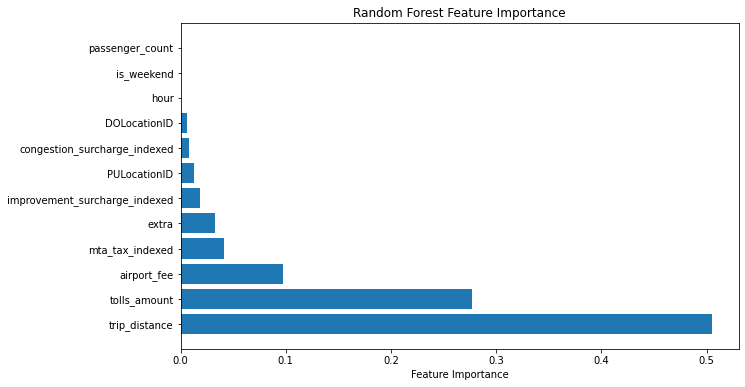

In [0]:
# Look into feature importance in random forest regression
best_rf_model = rf_cv_model.bestModel
rf_model = best_rf_model.stages[-1]

# Get feature importance from the Random Forest model
feature_importances = rf_model.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features3, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

## GBT Regressor

In [0]:
# GBT model and grid search
gbt = GBTRegressor(featuresCol="features3", labelCol="total_amount", seed=42)
gbt_paramGrid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxBins, [16, 32])
    .build()
)

# Create a Pipeline (gbt_pipeline)
gbt_pipeline = Pipeline(stages = [assembler3, gbt])

mlflow.pyspark.ml.autolog(disable=True) 

gbt_cv = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3
)

with mlflow.start_run(run_name="GBT_Model"):
    gbt_cv_model = gbt_cv.fit(train_data)
    predictions = gbt_cv_model.transform(val_data)

    # Log all tested parameter combinations
    for params, metric in zip(gbt_cv_model.getEstimatorParamMaps(), gbt_cv_model.avgMetrics):
        param_str = "_".join([f"{param.name}_{val}" for param, val in params.items()])
        mlflow.log_metric(f"cv_rmse_{param_str}", metric)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 4.385230537748638
R^2: 0.934545243345519
MAE: 2.3468287579786486


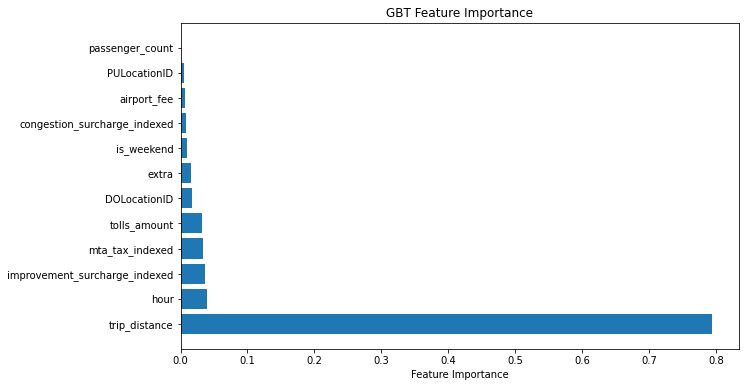

In [0]:
# Look into feature importance in GBT regression
best_gbt_model = gbt_cv_model.bestModel.stages[-1]

# Get feature importances from the GBT model
feature_importances = best_gbt_model.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features3, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("GBT Feature Importance")
plt.show()

## Update features
Update features based on feature importances to see if we can improve our model

In [0]:
features4 = [#'passenger_count',
 'PULocationID',
 'DOLocationID',
 'airport_fee',
 #'is_weekend',
 'hour',
 'mta_tax_indexed',
 'congestion_surcharge_indexed',
 'trip_distance',
 'extra',
 'tolls_amount']

assembler4 = VectorAssembler(inputCols=features4, 
outputCol='features4')

In [0]:
# RF model
rf = RandomForestRegressor(featuresCol="features4", labelCol="total_amount", seed=42)

# Grid search
rf_paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50])
    .addGrid(rf.maxDepth, [3, 5])
    .addGrid(rf.maxBins, [16, 32])
    .build()
)

mlflow.pyspark.ml.autolog(disable=True) 

# rf pipeline and cross validator
rf_pipeline = Pipeline(stages = [assembler4, rf])
rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3
)

with mlflow.start_run(run_name="RF_Model_features4"):
    rf_cv_model = rf_cv.fit(train_data)
    predictions = rf_cv_model.transform(val_data)

    # Log all tested parameter combinations
    for params, metric in zip(rf_cv_model.getEstimatorParamMaps(), rf_cv_model.avgMetrics):
        param_str = "_".join([f"{param.name}_{val}" for param, val in params.items()])
        mlflow.log_metric(f"cv_rmse_{param_str}", metric)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 6.024727597371868
R^2: 0.8764532902400156
MAE: 4.046701373269134


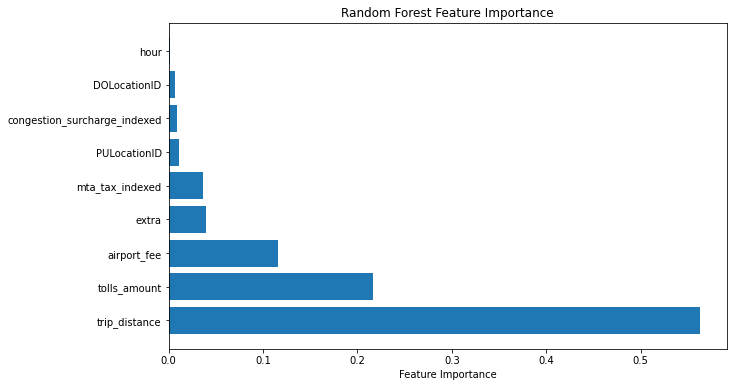

In [0]:
# Look into feature importance in random forest regression
best_rf_model_features4 = rf_cv_model.bestModel
rf_model = best_rf_model_features4.stages[-1]

# Get feature importance from the Random Forest model
feature_importances = rf_model.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features4, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [0]:
# GBT model and grid search
gbt = GBTRegressor(featuresCol="features4", labelCol="total_amount", seed=42)
gbt_paramGrid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxBins, [16, 32])
    .build()
)

# Create a Pipeline (gbt_pipeline)
gbt_pipeline = Pipeline(stages = [assembler4, gbt])

mlflow.pyspark.ml.autolog(disable=True) 

gbt_cv = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3
)

with mlflow.start_run(run_name="GBT_Model_features4"):
    gbt_cv_model = gbt_cv.fit(train_data)
    predictions = gbt_cv_model.transform(val_data)

    # Log all tested parameter combinations
    for params, metric in zip(gbt_cv_model.getEstimatorParamMaps(), gbt_cv_model.avgMetrics):
        param_str = "_".join([f"{param.name}_{val}" for param, val in params.items()])
        mlflow.log_metric(f"cv_rmse_{param_str}", metric)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 4.970438932942558
R^2: 0.9159097123957611
MAE: 2.9053918453611787


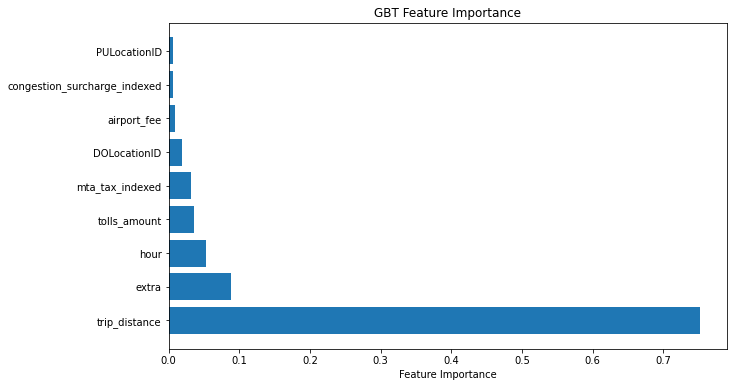

In [0]:
# Look into feature importance in GBT regression
best_gbt_model_features4 = gbt_cv_model.bestModel.stages[-1]

# Get feature importances from the GBT model
feature_importances = best_gbt_model_features4.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features4, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("GBT Feature Importance")
plt.show()

## Results 
Calculate test error and visualize predictions for the final model (GBT Regressor with features 3)

In [0]:
# Get predictions
test_data_assembled = assembler3.transform(test_data)
predictions = best_gbt_model.transform(test_data_assembled)

# Select actual and predicted values
results = predictions.select("total_amount", "prediction").toPandas()

In [0]:
rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

# Show results
print(f"RMSE: {rmse}")
print(f"R^2: {r2}")
print(f"MAE: {mae}")

RMSE: 4.444278789633991
R^2: 0.9331770134178405
MAE: 2.35629747308245


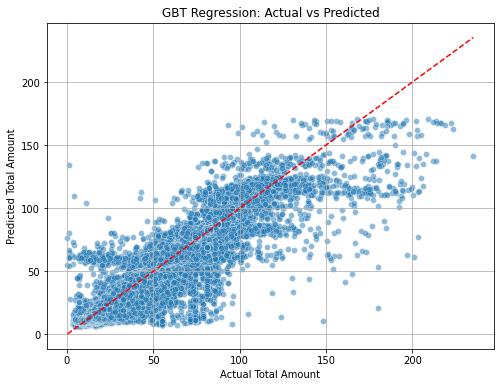

In [0]:
# Predicted vs Actual
plt.figure(figsize=(8, 6))
sns.scatterplot(data=results, x="total_amount", y="prediction", alpha=0.5)
plt.plot([results.total_amount.min(), results.total_amount.max()],
         [results.total_amount.min(), results.total_amount.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("GBT Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

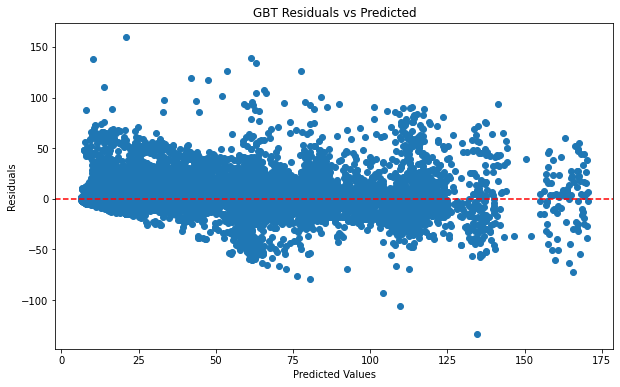

In [0]:
results["residuals"] = results["total_amount"] - results["prediction"]

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(results["prediction"], results["residuals"])
plt.axhline(0, color='red', linestyle="--")  # horizontal line at zero for reference
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("GBT Residuals vs Predicted")
plt.show()

Observations: The scatter plots reveal the presence of some trips for which the model's predictions are less accurate. However, there are no strong or systematic patterns in the residuals. For instance, we notice a gap around the predicted value of 150, but overall, the distribution appears balanced. This suggests that the final model performs consistently across the majority of data points.